<i>## Comments will be provided using this format. Key takeaway: groups are encouraged to change the formatting, but not the structure. Groups are also allowed to create additional notebooks - for instance, create one notebook for data exploration, and one notebook for each preprocessing-modelling-evaluation pipeline -, but must strive to keep an unified style across notebooks.</i>

#### NOVA IMS / BSc in Data Science / Text Mining 2025/2026
### <b>Group Project: "Straining the great southern Melting Pot"</b>
#### Notebook `Notebook Title`

#### Group:
- `Group member #1`
- `(...)`
- `Group member #5`

#### <font color='#BFD72'>Table of Contents </font> <a class="anchor" id='toc'></a> 
- [1. Data Understanding](#P1)
- [2. General Data Preparation](#P2) 
- [3. Multilabel Classification (Information Requirement 3311)](#P3)
    - [3.1 Specific Data Preparation](#P31)
    - [3.2 Model Implementation](#P32)
    - [3.3 Model Evaluation](#P3n)
- [4. Sentiment Analysis (Information Requirement 3312)](#P4)
    - [4.1 Specific Data Preparation](#P41)
    - [4.2 Model Implementation](#P42)
    - [4.3 Model Evaluation](#P43)
- [...]
- [N. Additional Tasks (Information Requirements 332n)](#Pn)
    - [N.1 Specific Data Preparation](#Pn1)
    - [N.2 Model Implementation](#Pn2)
    - [N.3 Model Evaluation](#Pn3)

<i>## Note that the notebook structure differs from the report: instead of following the CRISP-DM phases and then specifying the different problems inside the phases, the notebook is structured by problem, with the CRISP-DM phases being defined for each specific problem.

In [1]:
## All imports must be concentrated on a cell that immediately follow the table of contents
import time
import pandas as pd

<font color='#BFD72F' size=5>1. Data Understanding</font> <a class="anchor" id="P1"></a>
  
[Back to TOC](#toc)


Let's start buy reading the dataset

<font color='#BFD72F' size=5>2. Data Preprocessing</font> <a class="anchor" id="P1"></a>
  
[Back to TOC](#toc)

<i>## Use markdown cells to describe the purpose of the code cells that follow them.</i>

In [2]:
import pandas as pd
import re
import unicodedata
import nltk
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import seaborn as sns




In [3]:
atlanta_rest = pd.read_csv("data_atlanta/atlanta_restaurant_slice_2023.csv", header=0)
atlanta_rest

,title,categoryName,website,url,reviewsCount,stars,text
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr..."
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...
...,...,...,...,...,...,...,...
53561,L On North,New American restaurant,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Friday night dinner was Chicken Francaise. Jor...
53562,L On North,New American restaurant,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Great dinner.... Yay Jordan!!!!!!
53563,L On North,New American restaurant,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Jordan was our server and he was fantastic! Gr...
53564,L On North,New American restaurant,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Jordan was an amazing server! Great delicious...


In [3]:
atlanta_rest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53566 entries, 0 to 53565
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         53566 non-null  object 
 1   categoryName  53566 non-null  object 
 2   website       50600 non-null  object 
 3   url           53566 non-null  object 
 4   reviewsCount  53566 non-null  int64  
 5   stars         53566 non-null  float64
 6   text          53566 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 2.9+ MB


In [4]:
# Drop duplicates and rows without review text
atlanta_rest.drop_duplicates(subset=["text"], inplace=True)
atlanta_rest.dropna(subset=["text"], inplace=True)

In [5]:
# Drop the unneeded columns, rename the 'text' column to 'raw_text', and change its data type to 'string'.
atlanta_rest = atlanta_rest.drop(columns=["website","url"])
atlanta_rest = atlanta_rest.rename(columns={"text":"raw_content"})
atlanta_rest["raw_content"] = atlanta_rest["raw_content"].astype(str)
atlanta_rest.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51542 entries, 0 to 53565
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         51542 non-null  object 
 1   categoryName  51542 non-null  object 
 2   reviewsCount  51542 non-null  int64  
 3   stars         51542 non-null  float64
 4   raw_content   51542 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 2.4+ MB


Number of Reviews per Restaurant:
Minimum: 8
Maximum: 1075
Average: 174.72


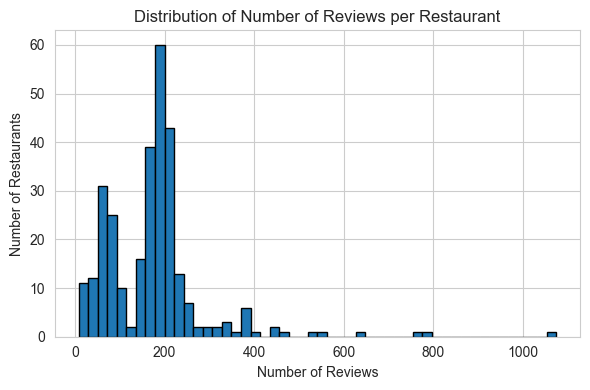

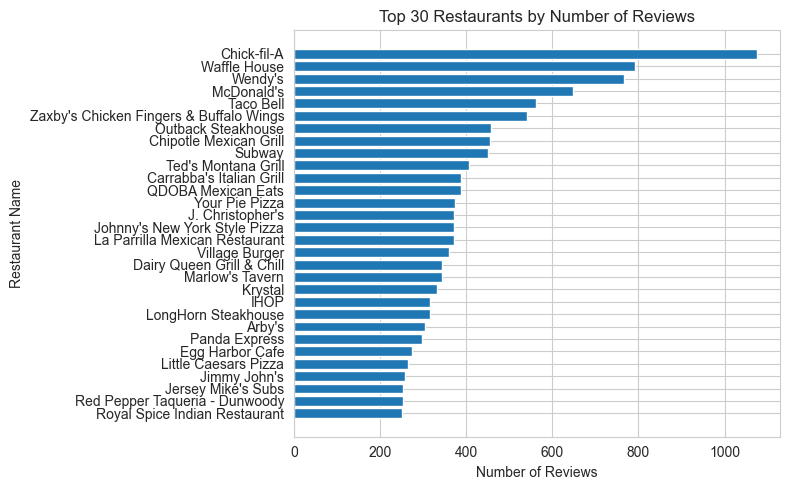

In [6]:
# === 1) GROUP AND COMPUTE REVIEW COUNTS ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Group reviews per restaurant into a dictionary: {restaurant_title: [list_of_reviews]}
reviews_per_restaurant = (
    atlanta_rest
    .groupby('title')['raw_content']
    .apply(list)
    .to_dict()
)

# Convert dictionary to a Pandas Series with counts
# This gives us: {restaurant_title: number_of_reviews}
counts_per_restaurant = (
    pd.Series({k: len(v) for k, v in reviews_per_restaurant.items()}, name='n_reviews')
    .sort_values(ascending=False)
)

# Convert to DataFrame for easier handling
counts_df = counts_per_restaurant.reset_index().rename(columns={'index': 'title'})

# Extract the counts array for statistics
num_reviews_per_restaurant = counts_df['n_reviews'].values

# Print basic descriptive statistics
print("Number of Reviews per Restaurant:")
print(f"Minimum: {np.min(num_reviews_per_restaurant)}")
print(f"Maximum: {np.max(num_reviews_per_restaurant)}")
print(f"Average: {np.mean(num_reviews_per_restaurant):.2f}")

# === 2) HISTOGRAM OF REVIEW DISTRIBUTION ===
plt.figure(figsize=(6, 4))
plt.hist(num_reviews_per_restaurant, bins=50, edgecolor='black')
plt.title('Distribution of Number of Reviews per Restaurant')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Restaurants')

# Uncomment this if the histogram is too skewed (long tail)
# plt.yscale('log')

plt.tight_layout()
plt.show()

# === 3) BAR CHART OF TOP-N RESTAURANTS ===
TOP_N = 30  # Choose how many restaurants to display
topN = counts_df.head(TOP_N)

plt.figure(figsize=(8, 5))
# Reverse the order so the bar chart goes from smallest to biggest from top to bottom (looks nicer)
plt.barh(topN['title'][::-1], topN['n_reviews'][::-1])
plt.title(f'Top {TOP_N} Restaurants by Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Restaurant Name')
plt.tight_layout()
plt.show()


In [12]:
atlanta_rest.sample(5)

,title,categoryName,reviewsCount,stars,raw_content
452,Dirty Rascal,Italian restaurant,124,5.0,Everything we had was GREAT! There was nothing...
15385,Arby's,Fast food restaurant,676,5.0,Love the guy in drive thru he's great
31063,"LA PAPA ""Hot potato & Corn House""",Fast food restaurant,79,5.0,"There’s nothing like it, every time we come he..."
53393,L On North,New American restaurant,449,2.0,I really want to like this restaurant. It's cu...
8346,NFA Burger,Hamburger restaurant,1140,5.0,Literally the best burger you can have anywher...


       reviewsCount         stars
count  51542.000000  51542.000000
mean     922.828761      4.025979
std     1139.628413      1.463805
min        5.000000      1.000000
25%      404.000000      3.000000
50%      648.000000      5.000000
75%     1053.000000      5.000000
max    13268.000000      5.000000
              reviewsCount     stars
reviewsCount      1.000000  0.028316
stars             0.028316  1.000000


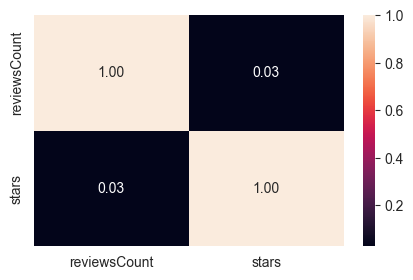

In [13]:


from matplotlib import pyplot as plt

print(atlanta_rest.describe())

numeric_atlanta_rest = atlanta_rest.select_dtypes(include=['int64', 'float64'])
corr = numeric_atlanta_rest.corr()
print(corr)

plt.figure(figsize=(5,3))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.show()

We do not have correlation between stars and review count.

In [14]:
atlanta_rest['categoryName'].nunique()


19

                categoryName  n_restaurants
0         Mexican restaurant             52
1        American restaurant             36
2         Italian restaurant             30
3           Pizza restaurant             23
4         Chinese restaurant             16
5       Fast food restaurant             16
6    New American restaurant             15
7         Seafood restaurant             15
8       Hamburger restaurant             11
9          Indian restaurant              9
10       Japanese restaurant              9
11  Mediterranean restaurant              9
12           Thai restaurant              9
13      Breakfast restaurant              8
14        Chicken restaurant              8
15             Sandwich shop              8
16               Steak house              8
17               Bar & grill              7
18       Barbecue restaurant              7


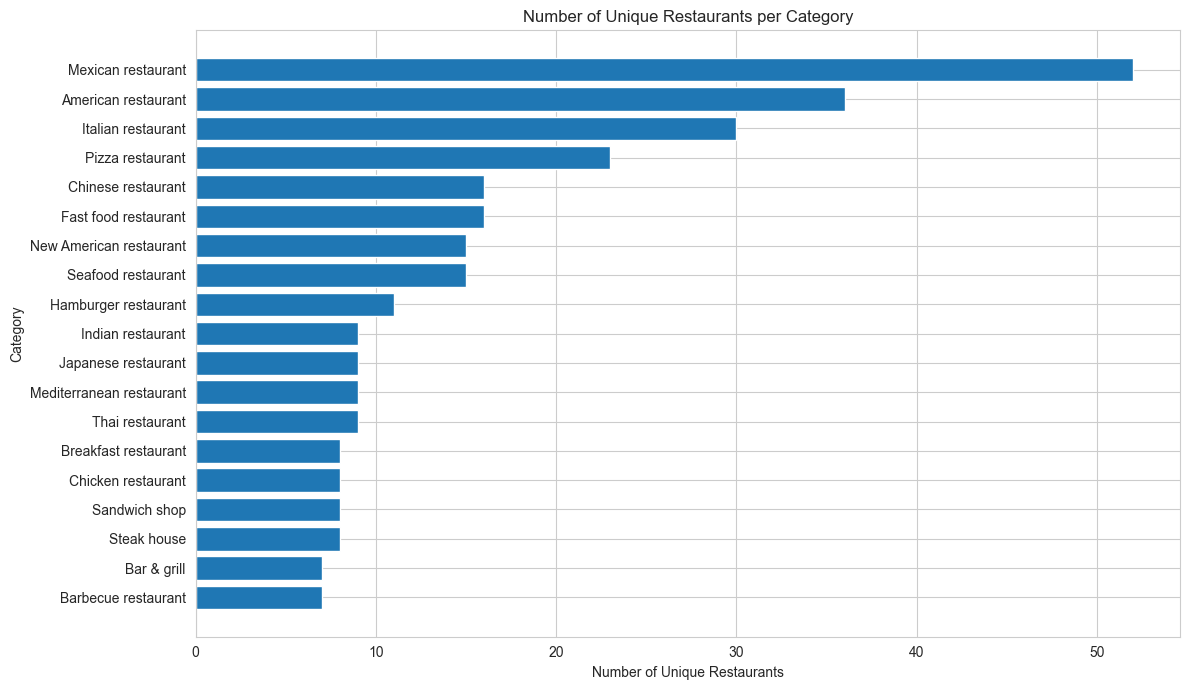

In [15]:
# === COUNT UNIQUE RESTAURANTS PER CATEGORY (ALL CATEGORIES) ===
import pandas as pd
import matplotlib.pyplot as plt

# Count unique restaurants per category
restaurants_per_category = (
    atlanta_rest
    .groupby('categoryName')['title']
    .nunique()
    .sort_values(ascending=False)
)

# Print the result as a table
restaurants_per_category_df = restaurants_per_category.reset_index()
restaurants_per_category_df.columns = ['categoryName', 'n_restaurants']
print(restaurants_per_category_df)

# Plot bar chart for all categories
plt.figure(figsize=(12, 7))
plt.barh(restaurants_per_category.index[::-1], restaurants_per_category.values[::-1])
plt.title('Number of Unique Restaurants per Category')
plt.xlabel('Number of Unique Restaurants')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


In [7]:
print("Columns after cleaning:", atlanta_rest.columns.tolist())

Columns after cleaning: ['title', 'categoryName', 'reviewsCount', 'stars', 'raw_content']


In [8]:
# Check and count accents, symbols, and emojis in the reviews
accent_pattern = re.compile(r"[^\x00-\x7F]")  # detects non-ASCII (accents & special Unicode)
symbol_pattern = re.compile(r"[\u2600-\u26FF\u2700-\u27BF]")  # symbols, dingbats
emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map
                           u"\U0001F1E0-\U0001F1FF"  # flags
                           "]+", flags=re.UNICODE)

def has_accent(text):
    return bool(accent_pattern.search(str(text)))

def has_symbol(text):
    return bool(symbol_pattern.search(str(text)))

def has_emoji(text):
    return bool(emoji_pattern.search(str(text)))

# Checks and counts
atlanta_rest["has_accent"] = atlanta_rest["raw_content"].apply(has_accent)
atlanta_rest["has_symbol"] = atlanta_rest["raw_content"].apply(has_symbol)
atlanta_rest["has_emoji"] = atlanta_rest["raw_content"].apply(has_emoji)

print("Accents:", atlanta_rest["has_accent"].sum(), f"({atlanta_rest['has_accent'].mean():.2%})")
print("Symbols:", atlanta_rest["has_symbol"].sum(), f"({atlanta_rest['has_symbol'].mean():.2%})")
print("Emojis:", atlanta_rest["has_emoji"].sum(), f"({atlanta_rest['has_emoji'].mean():.2%})")


Accents: 7434 (14.42%)
Symbols: 355 (0.69%)
Emojis: 0 (0.00%)


In [9]:
def clean_text(text):
    """
    Basic text cleaning:
    - lowercasing
    - remove URLs, HTML, mentions, hashtags
    - remove non-letter characters and extra spaces
    """
    text = str(text).lower()                          # Lowercase
    text = re.sub(r"http\S+|www\S+", "", text)        # Remove URLs
    text = re.sub(r"<.*?>", "", text)                 # Remove HTML tags
    text = re.sub(r"@\w+", "", text)                  # Remove @mentions
    text = re.sub(r"#\w+", "", text)                  # Remove hashtags
    text = re.sub(r"[^a-z\s]", " ", text)             # Keep letters only
    text = re.sub(r"\s+", " ", text).strip()          # Remove extra spaces
    text = unicodedata.normalize('NFKD', text)        # Normalize unicode
    text = text.encode('ascii', 'ignore').decode('utf-8')
    punctuation_pattern = r"[\u0021-\u002F\u003A-\u003F\u005B-\u005F\u2010-\u2028]+" # Remove punctuation
    text = re.sub(punctuation_pattern, " ", text)
    
    text = re.sub(r"[^a-z\s]", " ", text)       # Keep letters only (remove emojis and special symbols)
    return text

In [10]:
# Apply the cleaning function
atlanta_rest["clean_text"] = atlanta_rest["raw_content"].apply(clean_text)

In [11]:
atlanta_rest

,title,categoryName,reviewsCount,stars,raw_content,has_accent,has_symbol,has_emoji,clean_text
0,The Optimist,Seafood restaurant,3349,5.0,"One word amazing!! The red fish, halibut, fr...",False,False,False,one word amazing the red fish halibut fried ri...
1,The Optimist,Seafood restaurant,3349,5.0,First time here and the food is great and the ...,False,False,False,first time here and the food is great and the ...
2,The Optimist,Seafood restaurant,3349,5.0,I recently had the pleasure of dining at Optim...,False,False,False,i recently had the pleasure of dining at optim...
3,The Optimist,Seafood restaurant,3349,5.0,Beautiful atmosphere and delicious food. All o...,True,False,False,beautiful atmosphere and delicious food all of...
4,The Optimist,Seafood restaurant,3349,5.0,We had a wonderful dinner at the Optimist. Our...,False,False,False,we had a wonderful dinner at the optimist our ...
...,...,...,...,...,...,...,...,...,...
53561,L On North,New American restaurant,449,5.0,Friday night dinner was Chicken Francaise. Jor...,False,False,False,friday night dinner was chicken francaise jord...
53562,L On North,New American restaurant,449,5.0,Great dinner.... Yay Jordan!!!!!!,False,False,False,great dinner yay jordan
53563,L On North,New American restaurant,449,5.0,Jordan was our server and he was fantastic! Gr...,False,False,False,jordan was our server and he was fantastic gre...
53564,L On North,New American restaurant,449,5.0,Jordan was an amazing server! Great delicious...,False,False,False,jordan was an amazing server great delicious m...


Tokenisation

In [12]:
nltk.download('punkt_tab')
atlanta_rest["tokenised_content"] = atlanta_rest["clean_text"].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/viktoria/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [13]:
nltk.download('averaged_perceptron_tagger_eng')
atlanta_rest['pos_tags'] = atlanta_rest['tokenised_content'].apply(lambda tokens : [pos[1] for pos in pos_tag(tokens)])


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/viktoria/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [14]:
atlanta_rest

,title,categoryName,reviewsCount,stars,raw_content,has_accent,has_symbol,has_emoji,clean_text,tokenised_content,pos_tags
0,The Optimist,Seafood restaurant,3349,5.0,"One word amazing!! The red fish, halibut, fr...",False,False,False,one word amazing the red fish halibut fried ri...,"[one, word, amazing, the, red, fish, halibut, ...","[CD, NN, VBG, DT, JJ, NN, NN, VBD, NN, CC, NN,..."
1,The Optimist,Seafood restaurant,3349,5.0,First time here and the food is great and the ...,False,False,False,first time here and the food is great and the ...,"[first, time, here, and, the, food, is, great,...","[JJ, NN, RB, CC, DT, NN, VBZ, JJ, CC, DT, NN, ..."
2,The Optimist,Seafood restaurant,3349,5.0,I recently had the pleasure of dining at Optim...,False,False,False,i recently had the pleasure of dining at optim...,"[i, recently, had, the, pleasure, of, dining, ...","[NN, RB, VBD, DT, NN, IN, VBG, IN, NN, IN, JJ,..."
3,The Optimist,Seafood restaurant,3349,5.0,Beautiful atmosphere and delicious food. All o...,True,False,False,beautiful atmosphere and delicious food all of...,"[beautiful, atmosphere, and, delicious, food, ...","[NN, RB, CC, JJ, NN, DT, IN, DT, NN, NN, NN, I..."
4,The Optimist,Seafood restaurant,3349,5.0,We had a wonderful dinner at the Optimist. Our...,False,False,False,we had a wonderful dinner at the optimist our ...,"[we, had, a, wonderful, dinner, at, the, optim...","[PRP, VBD, DT, JJ, NN, IN, DT, JJ, PRP$, NN, I..."
...,...,...,...,...,...,...,...,...,...,...,...
53561,L On North,New American restaurant,449,5.0,Friday night dinner was Chicken Francaise. Jor...,False,False,False,friday night dinner was chicken francaise jord...,"[friday, night, dinner, was, chicken, francais...","[JJ, NN, NN, VBD, VBN, RB, NN, VBD, DT, JJ, NN..."
53562,L On North,New American restaurant,449,5.0,Great dinner.... Yay Jordan!!!!!!,False,False,False,great dinner yay jordan,"[great, dinner, yay, jordan]","[JJ, NN, NNS, NN]"
53563,L On North,New American restaurant,449,5.0,Jordan was our server and he was fantastic! Gr...,False,False,False,jordan was our server and he was fantastic gre...,"[jordan, was, our, server, and, he, was, fanta...","[NN, VBD, PRP$, NN, CC, PRP, VBD, JJ, JJ, NN]"
53564,L On North,New American restaurant,449,5.0,Jordan was an amazing server! Great delicious...,False,False,False,jordan was an amazing server great delicious m...,"[jordan, was, an, amazing, server, great, deli...","[NN, VBD, DT, JJ, NN, JJ, JJ, NN, CC, VB, JJ, ..."


Remove Stopwords

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

In [17]:
import nltk

from nltk.corpus import stopwords

stop_words = stopwords.words('english')
print(stop_words)
print(len(stop_words))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/viktoria/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


We analyse word clouds per category and decided to delete additional stopwords related to the restorant and food domain. You can see pictures of the word clouds before additional stopwords in the "wordclouds_by_category_before_removing_additional_stopwords" folder.

In [18]:
stop_words = set(stopwords.words("english"))

# Add domain-specific stopwords
extra_stopwords = {
    'food','restaurant','restaurants','place','menu','order','ordered','service','staff',
    'like','really','also','just','one','get','got','time','day','night','visit','visited',
    'good','great','nice','amazing','awesome','best','love','loved','delicious','tasty',
    'atlanta','buckhead','downtown','midtown','amp', 'always', 'excellent', 'great', 'experience', 'go', 'customer', 'location', 'friendly', 'table', 'back', 'try', 'tried'
}
stop_words = stop_words.union(extra_stopwords)

lemmatizer = WordNetLemmatizer()

def normalise_tokens(tokens):
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

atlanta_rest["norm_tokens"] = atlanta_rest["tokenised_content"].apply(normalise_tokens)
atlanta_rest["processed_text"] = atlanta_rest["norm_tokens"].apply(lambda x: " ".join(x))


[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/viktoria/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/viktoria/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [31]:
atlanta_rest['norm_tokens']

0        [word, red, fish, halibut, fried, rice, brocco...
1                                          [first, waiter]
2        [recently, pleasure, dining, optimist, ga, let...
3        [beautiful, atmosphere, flavorful, overall, oy...
4        [wonderful, dinner, optimist, group, meal, oys...
                               ...                        
53561    [friday, dinner, chicken, francaise, jordan, s...
53562                                [dinner, yay, jordan]
53563                    [jordan, server, fantastic, meal]
53564    [jordan, server, meal, wine, social, distancin...
53565                   [well, spaced, table, live, music]
Name: norm_tokens, Length: 51542, dtype: object

In [19]:
import os
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# group all processed text by category
texts_by_cat = (
    atlanta_rest
      .groupby("categoryName")["processed_text"]
      .apply(lambda s: " ".join(s))
      .to_dict()
)

os.makedirs("wordclouds", exist_ok=True)

# generate + save
for cat, text in texts_by_cat.items():
    wc = WordCloud(width=1000, height=700, background_color="white").generate(text)
    wc.to_file(f"wordclouds/{cat}.png")

# show all in grid
cats = list(texts_by_cat.keys())
n = len(cats)
cols = 3
rows = (n + cols - 1) // cols

plt.figure(figsize=(5.5*cols, 4.2*rows))
i = 1
for cat in cats:
    img = plt.imread(f"wordclouds/{cat}.png")
    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(cat)
    i += 1
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

TF-IDF Vectorization with uni and bi grams

In [35]:
atlanta_rest.columns

Index(['title', 'categoryName', 'reviewsCount', 'stars', 'raw_content',
       'has_accent', 'has_symbol', 'has_emoji', 'clean_text',
       'tokenised_content', 'pos_tags', 'norm_tokens', 'processed_text'],
      dtype='object')

Train Test Split

In [31]:
from sklearn.model_selection import train_test_split

X_train_before_tfidf, X_test_before_tfidf, y_train, y_test = train_test_split(
    atlanta_rest["processed_text"], 
    atlanta_rest["categoryName"], 
    test_size=0.2, 
    random_state=42
)


TF-IDF Vectorization with uni and bi grams

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# 1. Initialize TF-IDF Vectorizer with Uni, Bi, and Tri-grams
tfidf = TfidfVectorizer(
    ngram_range=(1, 3), 
    min_df=5,             
    max_df=0.8,           
    max_features=25000,  
    sublinear_tf=True    
)

# 2. Fit and Transform the Training Data

X_train = tfidf.fit_transform(X_train_before_tfidf)

# 3. Transform the Test Data
X_test = tfidf.transform(X_test_before_tfidf)

# 4. Inspect the resulting shapes and features
print("Train TF-IDF shape:", X_train.shape)
print("Test TF-IDF shape:", X_test.shape)

feature_names = np.array(tfidf.get_feature_names_out())

# Print some random examples of features to check if trigrams are present
print("\nExample features (including trigrams):")
# We grab a slice from the middle/end where longer n-grams might reside
print(feature_names[15000:15010])

Train TF-IDF shape: (41233, 18996)
Test TF-IDF shape: (10309, 18996)

Example features (including trigrams):
['side side' 'side still' 'side tasted' 'side thing' 'side town'
 'side well' 'sidewalk' 'siempre' 'siete' 'siete taco']


Logistic Regression Classifier

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize Logistic Regression with 'balanced' class weights
# This automatically assigns higher weights to minority classes (e.g., 'New American')
# and lower weights to majority classes (e.g., 'Mexican')
clf = LogisticRegression(
    max_iter=2000,
    n_jobs=-1,
    class_weight='balanced',  
    random_state=42          
)

# Train the model
clf.fit(X_train, y_train)

# Predict on the test set
y_pred = clf.predict(X_test)

# Evaluate model performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred))

# Generate confusion matrix
# We use clf.classes_ to ensure the labels match the order learned by the model
labels_sorted = clf.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)
print("\nConfusion matrix shape:", cm.shape)

/opt/anaconda3/envs/text_mining/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy: 0.48152100106702883

Classification report:

                          precision    recall  f1-score   support

     American restaurant       0.45      0.24      0.31       986
             Bar & grill       0.22      0.44      0.30       219
     Barbecue restaurant       0.50      0.61      0.55       223
    Breakfast restaurant       0.40      0.48      0.44       465
      Chicken restaurant       0.33      0.46      0.38       315
      Chinese restaurant       0.44      0.52      0.48       482
    Fast food restaurant       0.39      0.54      0.46       998
    Hamburger restaurant       0.56      0.59      0.58       387
       Indian restaurant       0.57      0.60      0.58       337
      Italian restaurant       0.67      0.38      0.48      1015
     Japanese restaurant       0.45      0.51      0.47       268
Mediterranean restaurant       0.29      0.49      0.37       265
      Mexican restaurant       0.84      0.50      0.63      1716
 New American restau

Logistic Regression with SMOTE (Synthetic Minority Over-sampling Technique)

In [44]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Initialize SMOTE
# random_state ensures reproducibility.
smote = SMOTE(random_state=42)

# 2. Apply SMOTE to the training data ONLY
# This generates synthetic samples for minority classes to balance the dataset.
# IMPORTANT: We never apply SMOTE to the test set to avoid data leakage.
print(f"Original training shape: {X_train.shape}")
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"Resampled training shape: {X_train_resampled.shape}")

# 3. Initialize the Classifier
# Note: We do NOT need class_weight='balanced' anymore because SMOTE 
# has already balanced the classes physically.
clf_smote = LogisticRegression(
    max_iter=2000, 
    n_jobs=-1, 
    random_state=42
)

# 4. Train the model on the resampled (balanced) data
clf_smote.fit(X_train_resampled, y_train_resampled)

# 5. Predict on the original test set
# We use the original test data to evaluate real-world performance.
y_pred_smote = clf_smote.predict(X_test)

# 6. Evaluate
print("Accuracy (with SMOTE):", accuracy_score(y_test, y_pred_smote))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_smote))

# Optional: Confusion Matrix to see where the model is confused
labels_sorted = clf_smote.classes_
cm = confusion_matrix(y_test, y_pred_smote, labels=labels_sorted)
print(f"\nConfusion Matrix Shape: {cm.shape}")

ImportError: cannot import name '_is_pandas_df' from 'sklearn.utils.validation' (/opt/anaconda3/envs/text_mining/lib/python3.12/site-packages/sklearn/utils/validation.py)

In [38]:
# Check installed versions
import sklearn
import sys

print("Python:", sys.version)
print("sklearn:", sklearn.__version__)

try:
    import imblearn
    print("imblearn:", imblearn.__version__)
except Exception as e:
    print("imblearn import error:", repr(e))


Python: 3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:07:49) [Clang 20.1.8 ]
sklearn: 1.8.0
imblearn import error: ImportError("cannot import name '_is_pandas_df' from 'sklearn.utils.validation' (/opt/anaconda3/envs/text_mining/lib/python3.12/site-packages/sklearn/utils/validation.py)")


Random Forest Classifier

In [34]:
# Random Forest on TF-IDF features (note: TF-IDF is sparse; we densify a reduced feature set)

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Reduce dimensionality before Random Forest (keeps it feasible)
k = 3000  # tune: 1000-10000 depending on your data size
selector = SelectKBest(score_func=chi2, k=k)

X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)

# Convert to dense arrays (RandomForest typically expects dense input)
X_train_dense = X_train_sel.toarray()
X_test_dense = X_test_sel.toarray()

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_dense, y_train)

# Predict and evaluate
y_pred = rf.predict(X_test_dense)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.4625084877291687

Classification report:

                          precision    recall  f1-score   support

     American restaurant       0.29      0.26      0.27       986
             Bar & grill       0.35      0.21      0.27       219
     Barbecue restaurant       0.64      0.52      0.57       223
    Breakfast restaurant       0.45      0.37      0.41       465
      Chicken restaurant       0.34      0.33      0.33       315
      Chinese restaurant       0.50      0.42      0.46       482
    Fast food restaurant       0.47      0.50      0.48       998
    Hamburger restaurant       0.54      0.52      0.53       387
       Indian restaurant       0.70      0.53      0.60       337
      Italian restaurant       0.49      0.41      0.45      1015
     Japanese restaurant       0.55      0.43      0.48       268
Mediterranean restaurant       0.53      0.34      0.41       265
      Mexican restaurant       0.40      0.72      0.52      1716
 New American restaur

Linear SVC 

In [26]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize Linear Support Vector Classifier (SVM)
# SVMs usually work better than Logistic Regression for high-dimensional text data (TF-IDF)
# class_weight='balanced' is still useful here
clf_svm = LinearSVC(
    class_weight='balanced', 
    random_state=42,
    dual=False,     
    max_iter=3000
)

# Train
clf_svm.fit(X_train, y_train)

# Predict
y_pred_svm = clf_svm.predict(X_test)

# Evaluate
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nSVM Classification report:\n")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.4870501503540596

SVM Classification report:

                          precision    recall  f1-score   support

     American restaurant       0.42      0.28      0.34       981
             Bar & grill       0.19      0.33      0.24       211
     Barbecue restaurant       0.44      0.59      0.50       221
    Breakfast restaurant       0.41      0.44      0.43       475
      Chicken restaurant       0.37      0.47      0.41       335
      Chinese restaurant       0.41      0.45      0.43       475
    Fast food restaurant       0.56      0.52      0.54      1016
    Hamburger restaurant       0.49      0.58      0.53       385
       Indian restaurant       0.59      0.61      0.60       343
      Italian restaurant       0.61      0.43      0.50       995
     Japanese restaurant       0.44      0.49      0.46       293
Mediterranean restaurant       0.35      0.43      0.39       281
      Mexican restaurant       0.60      0.58      0.59      1710
 New American

Different classifiers for each similar categories

In [45]:
# === 1. Define the Custom Taxonomy ===
# Dictionary mapping specific restaurant types to your 7 defined meta-classes
meta_mapping = {
    'Mexican restaurant': 'Mexican',
    
    'Italian restaurant': 'European',
    'Pizza restaurant': 'European',
    'Mediterranean restaurant': 'European',
    
    'Chinese restaurant': 'Asian',
    'Japanese restaurant': 'Asian',
    'Thai restaurant': 'Asian',
    'Indian restaurant': 'Asian',
    
    'American restaurant': 'American',
    'New American restaurant': 'American',
    'Bar & grill': 'American',
    'Hamburger restaurant': 'American',
    
    'Fast food restaurant': 'Fast_Food',
    'Sandwich shop': 'Fast_Food',
    'Chicken restaurant': 'Fast_Food',
    'Breakfast restaurant': 'Fast_Food',
    
    'Steak house': 'Meat_BBQ',
    'Barbecue restaurant': 'Meat_BBQ',
    
    'Seafood restaurant': 'Seafood'
}

# === 2. Apply Mapping ===
# Create a new column 'meta_category' using the dictionary
atlanta_rest['meta_category'] = atlanta_rest['categoryName'].map(meta_mapping)

# === 3. Validation ===
# Check if any rows were missed (should be 0)
missing_count = atlanta_rest['meta_category'].isna().sum()
print(f"Rows without a meta-category: {missing_count}")

# Print the distribution of the new meta-classes to check balance
print("\nDistribution of new Meta-Categories:")
print(atlanta_rest['meta_category'].value_counts())

Rows without a meta-category: 0

Distribution of new Meta-Categories:
meta_category
Fast_Food    10894
European     10761
American      9754
Mexican       8549
Asian         6771
Meat_BBQ      2836
Seafood       1977
Name: count, dtype: int64


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

# We need both the specific label (y_fine) and the broad group (y_meta)
X = atlanta_rest["processed_text"]
y_fine = atlanta_rest["categoryName"]    # 19 classes
y_meta = atlanta_rest["meta_category"]   # 7 classes

# 1. Split the data
# We stratify by the fine-grained category to ensure all small classes are represented
X_train_raw, X_test_raw, y_fine_train, y_fine_test, y_meta_train, y_meta_test = train_test_split(
    X, y_fine, y_meta, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_fine
)

# 2. Vectorization (TF-IDF)
# Using Uni-Bi-Trigrams as discussed
tfidf = TfidfVectorizer(
    ngram_range=(1, 3), 
    min_df=5, 
    max_df=0.8, 
    max_features=25000, 
    sublinear_tf=True
)

X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)

print(f"Train shape: {X_train.shape}")

Train shape: (41233, 18983)


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import numpy as np

# Dictionary to store our sub-classifiers
sub_classifiers = {}

# === STEP A: TRAIN THE PARENT MODEL (META-CLASSIFIER) ===
# This model learns to distinguish between "Asian", "European", "Mexican", etc.
print("Training Parent Model (Meta-Classifier)...")

clf_parent = LinearSVC(
    class_weight='balanced', 
    random_state=42,
    dual=False 
)
clf_parent.fit(X_train, y_meta_train)


# === STEP B: TRAIN CHILD MODELS (SUB-CLASSIFIERS) ===
unique_meta_groups = y_meta_train.unique()

for group in unique_meta_groups:
    
    # 1. Find indices of samples belonging to this group in the training set
    # FIX: We add .values or .to_numpy() to convert the Pandas Series to a Numpy array.
    # Scipy sparse matrices require Numpy arrays for boolean indexing.
    indices = (y_meta_train == group).values
    
    # 2. Get the specific sub-labels for this group
    # Pandas Series (y_fine_train) can handle numpy array indexing fine.
    sub_labels = y_fine_train[indices]
    
    # 3. Check how many unique sub-classes are in this group
    unique_sub_classes = sub_labels.unique()
    
    # If the group has only 1 class, we don't need a sub-model.
    if len(unique_sub_classes) <= 1:
        print(f"Skipping sub-model for '{group}' (only 1 subclass: {unique_sub_classes[0]})")
        sub_classifiers[group] = "is_leaf" 
        continue
        
    # 4. Train a specific classifier for this group
    print(f"Training sub-model for group '{group}' with classes: {unique_sub_classes}")
    
    sub_clf = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        n_jobs=-1,
        random_state=42
    )
    
    # Now X_train[indices] works because indices is a numpy array
    sub_clf.fit(X_train[indices], sub_labels)
    
    # Store the trained model in our dictionary
    sub_classifiers[group] = sub_clf

print("Training complete.")

Training Parent Model (Meta-Classifier)...
Training sub-model for group 'Asian' with classes: ['Thai restaurant' 'Chinese restaurant' 'Japanese restaurant'
 'Indian restaurant']


/opt/anaconda3/envs/text_mining/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Training sub-model for group 'European' with classes: ['Italian restaurant' 'Pizza restaurant' 'Mediterranean restaurant']


/opt/anaconda3/envs/text_mining/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Skipping sub-model for 'Seafood' (only 1 subclass: Seafood restaurant)
Training sub-model for group 'Fast_Food' with classes: ['Fast food restaurant' 'Chicken restaurant' 'Breakfast restaurant'
 'Sandwich shop']


...

Training sub-model for group 'Meat_BBQ' with classes: ['Barbecue restaurant' 'Steak house']


/opt/anaconda3/envs/text_mining/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Skipping sub-model for 'Mexican' (only 1 subclass: Mexican restaurant)
Training sub-model for group 'American' with classes: ['Hamburger restaurant' 'New American restaurant' 'American restaurant'
 'Bar & grill']


/opt/anaconda3/envs/text_mining/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Training complete.


In [49]:
from sklearn.metrics import accuracy_score, classification_report

def hierarchical_predict(parent_model, sub_models_dict, X_data):
    """
    Custom function to predict classes hierarchically.
    """
    # 1. Predict the Meta-Category for all samples
    meta_predictions = parent_model.predict(X_data)
    
    final_predictions = []
    
    # 2. Iterate through each prediction and refine it
    # Note: iterating row-by-row is slow for massive data, but fine for 10k rows.
    # For production, we would use masking (vectorized approach).
    for i, meta_pred in enumerate(meta_predictions):
        
        # Get the row vector
        row_vector = X_data[i]
        
        # Check if we have a sub-model for this group
        if meta_pred in sub_models_dict:
            handler = sub_models_dict[meta_pred]
            
            if handler == "is_leaf":
                # If it's a leaf group (e.g., Mexican), the meta-prediction implies the specific class
                # We need to map the group name back to the specific class name manually or assume logic
                # For this specific dataset logic:
                if meta_pred == 'Mexican':
                    final_predictions.append('Mexican restaurant')
                elif meta_pred == 'Seafood':
                    final_predictions.append('Seafood restaurant')
                else:
                    # Fallback
                    final_predictions.append(meta_pred) 
            else:
                # Use the sub-model to predict the fine-grained class
                sub_pred = handler.predict(row_vector)[0]
                final_predictions.append(sub_pred)
        else:
            # Fallback if something goes wrong (shouldn't happen)
            final_predictions.append(meta_pred)
            
    return np.array(final_predictions)

# === RUN PREDICTION ===
y_pred_hierarchical = hierarchical_predict(clf_parent, sub_classifiers, X_test)

# === EVALUATE ===
print("Hierarchical Accuracy:", accuracy_score(y_fine_test, y_pred_hierarchical))
print("\nClassification Report:\n")
print(classification_report(y_fine_test, y_pred_hierarchical))

Hierarchical Accuracy: 0.48569211368706955

Classification Report:

                          precision    recall  f1-score   support

     American restaurant       0.37      0.28      0.32       981
             Bar & grill       0.27      0.35      0.30       211
     Barbecue restaurant       0.58      0.57      0.58       221
    Breakfast restaurant       0.41      0.45      0.43       475
      Chicken restaurant       0.39      0.44      0.41       335
      Chinese restaurant       0.43      0.41      0.42       475
    Fast food restaurant       0.42      0.56      0.48      1016
    Hamburger restaurant       0.59      0.57      0.58       385
       Indian restaurant       0.71      0.61      0.65       343
      Italian restaurant       0.55      0.42      0.48       995
     Japanese restaurant       0.52      0.48      0.50       293
Mediterranean restaurant       0.41      0.41      0.41       281
      Mexican restaurant       0.64      0.57      0.60      1710
 New Am